<a href="https://colab.research.google.com/github/deltorobarba/science/blob/main/dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="blue">**Quantum Dynamics**


![science](https://raw.githubusercontent.com/deltorobarba/science/main/science.JPG)

In [ ]:
!pip install cirq cirq-ionq -q
# ⚠️ Restart kernel

In [ ]:
import cirq_ionq # https://docs.ionq.com/sdks/cirq
import cirq      # https://quantumai.google/cirq/hardware/ionq/circuits
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<font color="blue">**Quantum Dynamics: Schrödinger Equation  $|\psi(t)\rangle = e^{-iHt} |\psi(0)\rangle$**

Quantum systems in chemistry and physics can be described and computed with either classical and quantum methods:

* **Model**: Classical (Newton Mechanics) vs Quantum (Schrödinger equation)
* **Type**: Static (State) vs Dynamical (Evolution)
* **Computing**: Classical Computing vs Quantum Computing

<font color="blue">*1. Classical (Newtonian) Mechanics (**Static and Dynamic**): $F = m \cdot a$*
* Ignores electrons and consider atoms as spheres connected by springs (force fields)
* **Classical - Dynamic**: Molecular dynamics (MD). How proteins enfold and move? GROMACS, NAMD, AMBER.
* **Classical - Static**: Molecular Docking / Energy Minimization. Geometrically: Does medication fit to enzyme? AutoDock, Rosetta.
* **Quantum computing methods:** Future: Navier Stokes (fluid dynamics) with HHL to solve linear systems and differential equations exponentially faster than classical computers. For weather and climate: simulate weather with a much finer grid (e.g. 100m)

<font color="blue">*2. Quantum Mechanics (**Static**): Time-independent Schrödinger Equation $\hat{H}|\psi\rangle = E|\psi\rangle$*
* Includes electrons. **Approximates Ground State via optimization** with variation $\delta \langle H \rangle = 0$ to find global optimum in energy landscape. Stationary state important for calculating binding energies: If $\psi$ is an eigenstate of $\hat{H}$, then time evolution is trivial: $\Psi(t) = \psi e^{-iEt/\hbar}$. Probability density $|\Psi(t)|^2$ remains constant over time = states are stationary.
* **Classical computing:** Hartree-Fock (mean field of $\psi$) but ignore correlation energies, DFT (electron density $\rho$) approximates correlation energies with functionals (but require correct functional assumed), Post-HF (Coupled cluster, configuration interaction) calculate correlation energies but only small systems since their complexity grows exponentially
* **Quantum computing** (**NISQ**): Variational Quantum Eigensolver. Quantum Advantage: finds correlation energy with entanglement.
  * In classical quantum chemistry, correlation energies are either ignored (HF), approximated (DFT), or, while theoretically calculable exactly, are only feasible for small quantum systems (post-Hartree-Fock methods like coupled cluster or configuration interaction).
  * For classical computers, complexity grows exponentially, this is why quantum computers will play a significant role in analyzing larger, more complex systems.

<font color="blue">*3. Quantum Mechanics (**Dynamic**): Time-dependent Schrödinger Equation $i\hbar \frac{\partial}{\partial t} \Psi(\mathbf{r}, t) = \hat{H} \Psi(\mathbf{r}, t)$*
* **Simulate Time Evolution** $e^{-i\hat{H}t}$ of Quantum State $|\Psi(t)\rangle = e^{-i\hat{H}t/\hbar} |\Psi(0)\rangle$ via Unitary Transformation. For Quantum Chaos, OTOC, Scrambling (Black Holes) reaction dynamics (observe how bonds break and reform during a collision). No forward theorem!
* **Classical computing**: Time-Dependent DFT (TD-DFT) used to classically calculate excitations (fluorescence, spectra). However only for short times and small systems. To solve the time-dependent equation $i\hbar \frac{\partial}{\partial t} \Psi = \hat{H} \Psi$ classically at scale, you have to apply operator $e^{-i\hat{H}t/\hbar}$ to wavefunction. In system with $N$ particles, complexity grows exponentially with $N$.
* **Quantum computing** (**Fault-Tolerant**): Central challenge in quantum dynamics (Simulating Quantum Time Evolution):
  * Molecule evolves under all its forces (Kinetic + Potential) simultaneously, but QC can only do one. But unitary propagator $U(t) = e^{-i\hat{H}t}$ is implemented on quantum hardware that only supports a discrete set of elementary gates at once.
  * Three approaches: LCU, Trotterization, Qubitization (with Quantum Walks and Block Encoding). And with the OTOC metric to [measure information scrambling during quantum evolution](https://research.google/blog/a-verifiable-quantum-advantage/)


<font color="blue">*Why we can solve the Schrödinger equation analytically only for very small systems (Quantum Chemistry)*
* **Analytical** solution for Schrödinger in Hydrogen atom. But a second electron add electron-electron repulsion = three-body problem.
* **Approximate** Schrödinger with DFT and HF on classical computers via **optimization (variation)** for larger systems than Hydrogen
* **Simulate** time evolution for even larger systems = Quantum computer doesn't store information anymore - **it is the Hilbert space!**
* Weil die Schrödinger Gleichung nicht exakt lösbar für größere Systeme: Rayleigh Ritz Verfahren aus Variationsanalyse und Born-Oppenheimer Aporoximation (Nukleus fixed, Elektronen für Energy Potential). Modelle und Verfahren:
  * Valenzbindungstheorie (Hybridisierung, lokale Bindungen)
  * Molekülorbitaltheorie (Delokalisierung, Konjugation, Homo/Lumo, LCAO-Methode)
  * Hartee-Fock, Post-Hartree Fock (correlation energies), DFT
  * Quantum Numbers (Besonderheit: Spinquantenzahl. Normale“ Schrödinger-Gleichung liefert nur $n$, $l$ und $m_l$. Spin ($m_s$=± 1/2) quanten- mechanische Eigenschaft. Erscheint wenn Quantenmechanik + Speziellen RT kombiniert (1928 Dirac-Gleichung).

<font color="blue">*Qubitization (Quantum Walk, Block Encoding, LCU): Quantum Dynamics on fault-Tolerants QCs*

* (ps: Trotterization / Trotter-Suzuki is a less-efficient alternative for Hamiltonian Simulation suited for NISQ)
* Qubitization is an algebraic trick. It transforms the problem of walking through time into a problem of walking through the eigenvalues of an operator.
* **LCU Decomposition:**
  * Approximate operator by decomposing propagator $e^{-iHt}$ via Taylor series in weightes sum of unitaries $H = \sum_{l=0}^{L-1} \alpha_l U_l$. (non-unitary, represents energy).
  * Then **Normalization:** $\lambda = \sum |\alpha_k|$ $\rightarrow$ $H/\lambda$.
  * If $H=$ Dirac $\mathcal{D}$ = as benchmark, its algebraic structure (sum of Paulis) efficient.
* **LCU Oracles**:
  1. PREPARE Oracle ($P$): encodes coefficients $\alpha_j$ into amplitudes of ancilla. Output is state where probability of measuring state $j$ is proportional to $\alpha_j$: $P|0\rangle = \frac{1}{\sqrt{\|\alpha\|_1}} \sum_{j=0}^{m-1} \sqrt{\alpha_j} |j\rangle$.
  2. SELECT Oracle ($S$) apply unitaries $U_l$ to target register state, conditioned on state of ancilla (entangles). If ancilla is state $|j\rangle$, it applies $U_j$ to target state $|\psi\rangle$. $S = \sum_{j=0}^{m-1} |j\rangle\langle j| \otimes U_j$
  3. Un-prepare: Apply inverse $P^\dagger$ to ancilla.
  4. Measure: ancilla.
* **Block Encoding $U_H$:**
  * LCU embeds $\hat{H}/\lambda$ in top-left corner of quantum walk $U_H = \begin{pmatrix} \hat{H}/\lambda & \dots \\ \dots & \dots \end{pmatrix}$.
  * If Ancilla is $|0\rangle$, we apply $H$. If Ancilla is $|1\rangle$, apply junk.
* **Quantum Walk** $Q$:
  * add reflections to $U$ turns it into walk that moves through energy spectrum.
  * By reflecting junk back into system ($Q = R \cdot U$), a rotation is created.
  * Eigenvalues of $Q$ are linked to eigenvalues $E$ of $H$ via $\mu = e^{\pm i \arccos(E/\lambda)}$ (energy mapping).
  * Physics is in angle (Isomorphism): $E_k = \lambda \cos(\theta_k)$.
  * QW transforms *energy information* (scalar magnitude) into *phase information* (how fast rotates).
  * High Energy $\rightarrow$ Small Angle. Zero Energy $\rightarrow$ $\cos(90^\circ)=0$.
* **Simulation: Qubitization for OTOC**
  * Example: OTOC (scrambling of black hole or complex molecule). Time Reversal in Qubitization: invert Reflection and Oracles. **Shows that TIME in Qubitization is actually an ANGLE in Hilbert space**.
  * Scrambling: Even with 1 system qubit, measurement changes if Forward and Backward walks don't perfectly cancel out because of the $X$ gate (butterfly). Code is gate-based with no god-mode access to $e^{-iHt}$.

<font color="blue">**Quantum Dynamics: Quantum Chaos, Scrambling & OTOCs**

A local operator under chaotic dynamics grows in three directions — each direction has its own metric:

* **Rate** (how fast?): quantum Lyapunov exponent $\lambda_L$ — slope of the OTOC growth
* **Reach** (how far?): butterfly velocity $v_B$ — slope of the light cone
* **Depth** (how deep into operator space?): Krylov complexity $K(t)$ — position on the Krylov chain
* **Bounds & consequences**: KMS $\Rightarrow$ UOGH $\Rightarrow$ MSS bound; scrambling as a resource (Hayden-Preskill) and as an obstacle (barren plateaus)

**Model system:** Simple chaotic Hamiltonian is mixed-field Ising: $H = \sum Z_i Z_{i+1} + h_x \sum X_i + h_z \sum Z_i$. Longitudinal field $h_z$ breaks integrability and turns it chaotic.

<font color="blue">*Definition — Four-Point Function, Heisenberg Picture, Measurement Protocol*

* **OTOCs** measure the scrambling of information. Given an operator W(t) at time t and an operator V(0) at time 0, the OTOC $ \langle W^\dagger(t) V^\dagger(0) W(t) V(0) \rangle $ measures **how strongly these operators fail to commute after time t**. The quantum-mechanical analogue of the butterfly effect.
* **OTOC** $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ is a metric to quantify quantum chaos and the rate of scrambling (quantum Lyapunov exponent). **Operator Spreading:** local operator $\hat{V}$ (Pauli gate) evolves under a chaotic Hamiltonian into a non-local operator $\hat{V}(t) = e^{iHt}\hat{V}e^{-iHt}$ (Eigenstate Thermalization)
* **Commutator vs. four-point form** — for unitary & Hermitian $W, V$: $C(t) = 2\left(1 - \mathrm{Re}\, F(t)\right)$ with $F(t) = \langle W^\dagger(t)\, V^\dagger\, W(t)\, V \rangle$. Scrambling: $F(t) \to 0$ while $C(t)$ saturates at $\sim 2\,\langle W^2\rangle\langle V^2\rangle$.
* **Why "out-of-time-order"** — the operator sequence runs $t \to 0 \to t \to 0$ along the time contour, which no time-ordered experiment can produce directly (it requires effective time reversal — hence the echo protocols). Ordinary time-ordered two-point functions $\langle W(t) V \rangle$ decay already at $t_{\text{therm}}$ and are blind to scrambling — the OTOC is the finer probe.
* **Time-Dependent Schrödinger** $|\Psi(t)\rangle = e^{-iHt} |\Psi(0)\rangle$ tells how the state moves. The OTOC describes whether the dynamics is chaotic or ordered. The time-dependent part is hidden in $\hat{W}(t)$.
* **Heisenberg Evolution** $\hat{W}(t) = e^{iHt} \hat{W}(0) e^{-iHt}$ to calculate $\hat{W}(t)$, where $e^{-iHt}$ is the solution to the Schrödinger equation. Without Schrödinger, no $\hat{W}(t)$ and no OTOC.
* **Four-Point Function:** evolve forward and backward in time: $W(t) = e^{iHt} W(0) e^{-iHt}$. Schrödinger (moving states) $\rightarrow$ Heisenberg (moving operators)
* **Regularized OTOC** — $\rho^{1/4}$ inserted symmetrically; the MSS proof lives on this function: $F(t) = \mathrm{Tr}\!\left[\rho^{1/4} W(t)\, \rho^{1/4} V\, \rho^{1/4} W(t)\, \rho^{1/4} V\right]$
* **Loschmidt Echo**: measure the OTOC on a QC: 1. Evolve forward ($e^{-iHt}$) 2. Perturbation ($\hat{V}$) 3. Evolve backward ($e^{+iHt}$ - time reversal) 4. Measure overlap
* The OTOC is calculated via the sequence: ***Forward Evolution***: Apply the Qubitization Walk $n$ times (simulating time $+t$). ***Perturbation***: Apply the Butterfly operator $\hat{V}$ ($X$ gate). ***Backward Evolution***: Apply the inverse Qubitization Walk $n$ times (simulating time $-t$). ***Measurement***: Apply the probe operator $\hat{W}$ and check the correlation.

*An OTOC is defined as $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$. The core concept here is Operator Spreading. We want to see how a local operator $\hat{W}$ at time $0$ evolves into a complex, non-local operator $\hat{W}(t) = \hat{U}^\dagger(t) \hat{W}(0) \hat{U}(t)$ at time $t$. We are asking: How much does the future measurement of $W$ depend on a past perturbation $V$? - If the system is chaotic, $\hat{W}(t)$ spreads across the system and eventually fails to commute with $\hat{V}(0)$, causing the OTOC to grow.*

<font color="blue">*Rate — Quantum Lyapunov Exponent $\lambda_L$ (temporal growth)*

* **Chaotic growth:** in a scrambler, $C(t) \simeq \frac{2K}{N}\, e^{\lambda_L t}$ with $\lambda_L$ the **quantum Lyapunov exponent** (rate of scrambling).
* **Semiclassical origin (Larkin-Ovchinnikov 1969)** — replace the commutator by the Poisson bracket: $-\langle [x(t), p]^2 \rangle \;\to\; \hbar^2 \left\langle \{x(t), p\}_{PB}^2 \right\rangle = \hbar^2 \left(\frac{\partial x(t)}{\partial x(0)}\right)^2 \sim \hbar^2 e^{2\lambda_{cl} t}$ — $\lambda_L$ is the quantum descendant of the classical Lyapunov exponent.
* **Operator size $n(t)$** — mean number of non-trivial Pauli factors in the Pauli-string decomposition of $W(t)$; grows exponentially until saturation: $\frac{dn}{dt} = \lambda_L\, n(t) \;\Rightarrow\; n(t) \sim e^{\lambda_L t}$
* **Operator-size distribution** — probability that $W(t)$ has size $n$; $C(t)$ is its first moment: $P(n,t) = \sum_{I:\,n(I)=n} |c_I(t)|^2$, $\quad C(t) \propto \frac{\langle n(t)\rangle}{N}$
* **Caveat (finite systems)** — a clean exponential Lyapunov regime needs a small parameter (large $N$, semiclassical $\hbar \to 0$, large local Hilbert space). In few-qubit spin chains the window between early growth and saturation is short, so $v_B$ and the light cone are extracted more reliably than $\lambda_L$.
* **Fast scrambling**: scrambling time is logarithmic in system size — black holes are conjectured to be the fastest scramblers in nature: $t_* \sim \frac{1}{\lambda_L} \ln N$
* **Timescale hierarchy:** $t_{\text{therm}} \sim \mathcal{O}(1) \;<\; t_*^{\text{scrambling}} \sim \ln N \;<\; t_K^{\text{Krylov}} \sim e^{S}$

<font color="blue">*Reach — Butterfly Velocity $v_B$, Light Cone, Lieb-Robinson (spatial growth)*

* **Butterfly velocity $v_B$** — spatial speed of the operator front; slope of the OTOC light cone: $C(t,x) \sim \frac{1}{N}\, e^{\lambda_L (t - x/v_B)}$
* **Quantum Butterfly Effect**: Calculate the OTOC between the first qubit and every other qubit. Shows how information spreads physically (the light cone of scrambling made visible).
* **Lieb-Robinson Light Cone (Bound)** (diagonal V-shape): information has a speed limit, the **Butterfly Velocity** $v_B$ (slope of the diagonal line), as it travels down the chain
* **Lieb-Robinson bound** — universal speed limit for information in local quantum systems: $\|[A(t), B]\| \leq C\, e^{-\mu (d - v_{LR} t)}$
* **$v_B$ vs. $v_{LR}$** — Lieb-Robinson is a state-independent operator-norm bound; the butterfly velocity is state/temperature-dependent and satisfies $v_B \leq v_{LR}$ (typically decreasing at low $T$).
* **Lieb-Robinson velocity** sets the universal speed limit on how fast information can propagate in a local quantum system. The speed limit shows up in three places: it's the slope of the OTOC light cone (the butterfly velocity), it's why RCS depth scales linearly with $n$ in 1D and as $\sqrt{n}$ in 2D, and it's the operator-spreading velocity in random unitary circuits.
* **Interaction strength $J$** — increasing it makes the slope steeper (information moves faster), and quantum chaos grows faster with $h_z$. The light cone of information scrambling.
* **Random Unitary Circuits (RUCs)**: brickwork of Haar-random 2-qubit gates; no Hamiltonian, maximally chaotic by construction.
* **Operator spreading in RUCs (Nahum-Vijay-Haah 2018)** — KPZ universality class: ballistic front with diffusive broadening: $\langle x_{\text{front}} \rangle = v_B\, t$, $\quad \sigma(t) \sim t^{1/3}$
* **Entanglement growth** — linear in $t$ with entanglement velocity $v_E \leq v_B$ (Mezei-Stanford bound): $S(t) = v_E\, t + \mathcal{O}(t^{1/3})$
* **Dual-unitary circuits**: gates unitary in both space and time directions; the OTOC vanishes *exactly* outside the light cone — exactly solvable, $v_B$ saturates Lieb-Robinson.
* **Measurement-induced phase transition (MIPT)** — at measurement rate $p$ per site: $S \propto L$ for $p < p_c$ (volume law), $S = \mathcal{O}(1)$ for $p > p_c$ (area law).
* **Poincaré Recurrence** (integrable regime, $h_z=0$) with ballistic echoes. Information remains particle-like and bounces back coherently to the original state.
* **Poincaré recurrence time**: the length of time a confined, closed physical system with finite phase-space volume takes to return to a state nearly identical to its initial configuration.
* **Quantum Chaos** (chaotic regime, $h_z\neq 0$). Information scrambles (thermalizes). By t=20, the system is a perfect model for how information is hidden in a Black Hole.

*$C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ quantifies the rate of scrambling. $\hat{V}(0)$: Butterfly (small local perturbation at start). $\hat{W}(t)$: measurement later in time. At $t=0$, $W$ and $V$ commute (they act on different qubits). The commutator is 0. As time evolves, $\hat{W}(t)$ grows spatially (scrambling). Eventually, $\hat{W}(t)$ hits the qubit where $\hat{V}$ sits. They no longer commute. The commutator grows, and $C(t)$ deviates from zero. Result: the rate at which the OTOC grows is the Lyapunov exponent ($\lambda$), the speed limit of chaos.*

<font color="blue">*Depth — Krylov Complexity, Spectral Statistics & Thermalization (ETH)*

* **Liouvillian** — superoperator generating Heisenberg evolution; its tridiagonalization defines the Krylov basis: $\mathcal{L} = [H, \cdot\,]$, $\quad O(t) = e^{i\mathcal{L}t} O$
* **Lanczos recursion** — tridiagonal form of $\mathcal{L}$ on the Krylov chain; $b_n$ = hopping amplitudes between Krylov sites: $\mathcal{L}|O_n) = b_{n+1}|O_{n+1}) + b_n |O_{n-1})$
* **Krylov complexity** — mean position on the Krylov chain; measures the algebraic depth of operator evolution: $K(t) = \sum_n n\, |\varphi_n(t)|^2$
* **Universal Operator Growth Hypothesis (UOGH)** — in non-integrable systems the $b_n$ grow linearly, with slope bounded by KMS analyticity: $b_n = \alpha n + \gamma + o(1)$, $\quad \alpha \leq \pi/\beta$
* **Growth regimes:** $b_n \to \text{const} \Rightarrow K \sim t$ (integrable) $\;|\;$ $b_n \sim \sqrt{n} \Rightarrow K \sim t^2$ (free) $\;|\;$ $b_n \sim \alpha n \Rightarrow K \sim e^{2\alpha t}$ (chaotic)
* **ETH ansatz (Srednicki)** — matrix elements of local operators in energy eigenstates: diagonal part thermal, off-diagonal exponentially suppressed: $A_{mn} = \mathcal{A}(\bar{E})\,\delta_{mn} + e^{-S(\bar{E})/2} f_A(\bar{E}, \omega)\, R_{mn}$
* **ETH core insight**: a single energy eigenstate already looks thermal locally — the system thermalizes *locally* while remaining globally pure.
* **Random Matrix Theory / BGS conjecture (Bohigas-Giannoni-Schmit 1984)** — the *static* fingerprint of chaos: chaotic spectra show Wigner-Dyson level repulsion (GOE/GUE), integrable spectra show Poisson statistics (Berry-Tabor). Mean gap ratio $\langle r \rangle \approx 0.53$ (GOE) vs. $\approx 0.39$ (Poisson) — the standard numerical test, complementary to the *dynamical* OTOC.
* **Spectral form factor (SFF)** — $\mathrm{SFF}(t) = |Z(\beta + it)|^2 / |Z(\beta)|^2$; universal **dip–ramp–plateau** shape, where the linear ramp is RMT level repulsion. Probes chaos at late times $t > t_*$, where the OTOC has already saturated.
* **Classification:** Chaotic: ETH holds $\;|\;$ Integrable: GGE $\;|\;$ MBL: no thermalization

<font color="blue">*Bounds — KMS $\Rightarrow$ UOGH $\Rightarrow$ MSS*

* **KMS condition** — links thermal correlators to imaginary time; source of analyticity in the strip $0 \leq \mathrm{Im}(t) \leq \beta$: $\langle A(t) B(0) \rangle_\beta = \langle B(0) A(t + i\beta) \rangle_\beta$
* **Logical stack** (algebraic principle → algorithmic bound): KMS analyticity $\;\Rightarrow\; \alpha \leq \pi/\beta \;\Rightarrow\; \lambda_L \leq 2\alpha \leq 2\pi/\beta$
* **MSS bound (Maldacena-Shenker-Stanford)**: $\lambda_L \leq 2\pi/\beta$. Conjecture that black holes are the fastest scramblers in nature. Ties scrambling to thermodynamics and black holes (which saturate the bound). Connects OTOCs to JT gravity, SYK, + the Hayden-Preskill protocol.
* **SYK model (Sachdev-Ye-Kitaev)** — $N$ Majorana fermions with random all-to-all four-body couplings; solvable at large $N$; **saturates the MSS bound** ($\lambda_L \to 2\pi/\beta$ at strong coupling); holographically dual to JT gravity — the canonical maximal scrambler.
* **Vikram-Shou-Galitski bound** — lower bound on scrambling time from entropy: $t_s \gtrsim \log S$

<font color="blue">*Consequences — Black Holes $\leftrightarrow$ Quantum Computing*

* **Scrambling ≠ information loss** — evolution is unitary: information is never destroyed, only delocalized from local observables into non-local, high-weight entanglement. Locally invisible, globally recoverable — the premise behind Hayden-Preskill.
* **Hayden-Preskill (2007)**: information dropped into a scrambler can be reconstructed from early radiation in time $\mathcal{O}(\ln N)$ — *if* you know the dynamics.
* **Yoshida-Kitaev decoder (2017)**: probabilistic protocol using two copies $U$ and $U^*$; exploits scrambling as a teleportation channel: Fidelity $\propto \langle W(t)^\dagger V^\dagger W(t) V \rangle_\beta$ (= OTOC). **Paradoxical consequence**: the decoder works *precisely when* the system scrambles maximally (OTOC → 0) — chaos becomes a transmission resource.
* **Porter-Thomas distribution** $P(p) \approx N e^{-Np}$ (with $N = 2^n$) is the histogram of bitstring probabilities in RCS. It is the fingerprint of a **Haar-random unitary**. The depth needed to **reach Porter-Thomas — the scrambling time** — is set by the circuit geometry: $d \sim n$ for a 1D chain, $d \sim \sqrt{n}$ for a 2D grid like Sycamore. This is the light cone from the **Lieb-Robinson bound** reaching across the device.
* **Page scrambling time** is when a system has thermalized so thoroughly that most qubits need to be measured to recover any local information. RCS is designed to push the system to Page scrambling as fast as possible → this is why it uses Haar-random gates rather than evolution under a specific Hamiltonian.
* **Minimum depth for global entanglement** (from Lieb-Robinson): $d_{\min} \sim n$ (1D), $\;\sim \sqrt{n}$ (2D), $\;\sim \log n$ (all-to-all).
* **Hamiltonian simulation** — Lieb-Robinson saturated by Haah-Hastings-Kothari-Low (2018); gate complexity is *scrambling-limited*: Gates $= \mathcal{O}\!\left(n t \cdot \mathrm{polylog}(1/\epsilon)\right)$
* **Barren plateaus (McClean et al. 2018)** — full scrambling → exponentially flat optimization landscape; VQAs become untrainable: $\mathrm{Var}[\partial_\theta E] \sim 2^{-n}$
* **Experimental OTOCs** — measured via echo protocols in NMR (Li et al. 2017) and trapped ions (Gärttner et al. 2017); **Google "Quantum Echoes" (2025)**: a second-order OTOC measured on the Willow chip, claimed as the first *verifiable* quantum advantage — the forward–perturb–backward circuit is exactly the Loschmidt-echo protocol above.

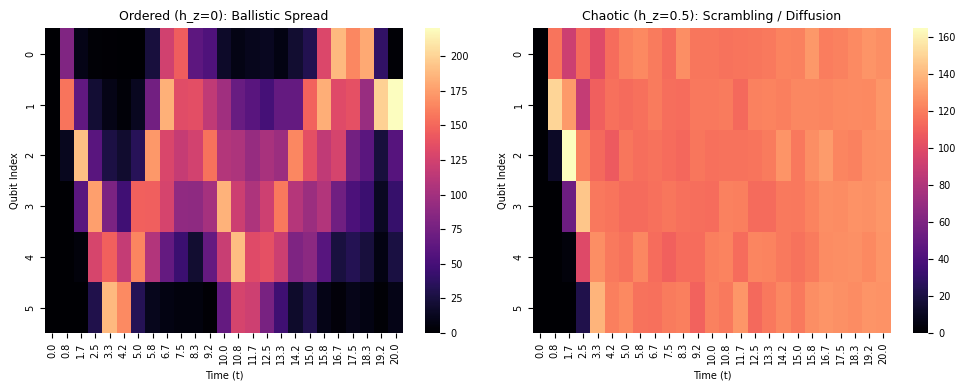

*$C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ quantifies rate of scrambling. $\hat{V}(0)$: Butterfly (small local perturbation at start). $\hat{W}(t)$ measurement later in time. At $t=0$, $W$ and $V$ commute (are on different qubits). Commutator is 0. As time evolves, $\hat{W}(t)$ grows spatially (scrambling). Eventually, $\hat{W}(t)$ hits the qubit where $\hat{V}$ sits. They no longer commute. Commutator grows, and $C(t)$ deviates from zero. Result: rate at which OTOC grows is Lyapunov Exponent ($\lambda$), the speed limit of chaos.*

In [ ]:
# @title OTOC: Light Cone of Scrambling

# OTOC for all qubits over time. Ordered vs Chaotic
from IPython.display import display, Markdown
from scipy.linalg import norm

def get_unitary_from_circuit(qubits, t, h_x, h_z, steps=25):
    """
    Creates the Unitary Matrix U(t) for a specific Hamiltonian setup.
    H = Sum(Zi Zj) + h_x * Sum(Xi) + h_z * Sum(Zi)
    """
    circuit = cirq.Circuit()
    dt = t / steps
    n = len(qubits)

    for _ in range(steps):
        # 1. Interaction (ZZ) - The "Scrambler"
        for i in range(n - 1):
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))
            circuit.append(cirq.rz(rads=2 * dt).on(qubits[i+1]))
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # 2. Transverse Field (X) - The "Driver"
        if h_x != 0:
            for i in range(n):
                circuit.append(cirq.rx(rads=2 * h_x * dt).on(qubits[i]))

        # 3. Longitudinal Field (Z) - The "Chaos Generator"
        # Adding this term breaks integrability and causes chaos.
        if h_z != 0:
            for i in range(n):
                circuit.append(cirq.rz(rads=2 * h_z * dt).on(qubits[i]))

    # Extract the full unitary matrix (2^N x 2^N)
    return cirq.unitary(circuit)

def calculate_otoc_heatmap(num_qubits, h_x, h_z, t_max, t_steps):
    """
    Calculates OTOC for all qubits over time to visualize the Light Cone.
    """
    qubits = cirq.LineQubit.range(num_qubits)
    times = np.linspace(0, t_max, t_steps)
    # Matrix to store results: Rows = Qubits, Cols = Time
    heatmap_data = np.zeros((num_qubits, t_steps))

    # V is always X on the first qubit (The "Butterfly")
    op_list_V = [np.eye(2)] * num_qubits
    op_list_V[0] = np.array([[0, 1], [1, 0]]) # Pauli X
    V = op_list_V[0]
    for i in range(1, num_qubits):
        V = np.kron(V, op_list_V[i])

    #print(f"Generating Heatmap (h_z={h_z})...")

    for t_idx, t in enumerate(times):
        if t == 0: continue

        # Get the global Unitary for this time point
        U = get_unitary_from_circuit(qubits, t, h_x, h_z) # Using previous function
        U_dag = U.conj().T

        # Calculate OTOC for each qubit j as the "Probe"
        for j in range(num_qubits):
            # W is Z on qubit j
            op_list_W = [np.eye(2)] * num_qubits
            op_list_W[j] = np.array([[1, 0], [0, -1]]) # Pauli Z

            # Construct W matrix
            W = op_list_W[0]
            for k in range(1, num_qubits):
                W = np.kron(W, op_list_W[k])

            # Heisenberg evolution: W(t) = U^dag * W * U
            W_t = U_dag @ W @ U

            # Commutator magnitude
            commutator = W_t @ V - V @ W_t
            heatmap_data[j, t_idx] = np.linalg.norm(commutator) ** 2

    return times, heatmap_data

# --- Execution ---
n_qubits = 6 # Kept small for simulation speed
t_max = 20.0
t_steps = 25

# Generate data for Chaotic vs Ordered
_, data_ordered = calculate_otoc_heatmap(n_qubits, 1.0, 0.0, t_max, t_steps)
times, data_chaotic = calculate_otoc_heatmap(n_qubits, 1.0, 0.5, t_max, t_steps)

# --- Plotting ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define your desired font size
small_size = 7

# Plot 1
sns.heatmap(data_ordered, ax=ax1, cmap='magma', xticklabels=np.round(times, 1))
ax1.set_title("Ordered (h_z=0): Ballistic Spread", fontsize=small_size + 2)
ax1.set_xlabel("Time (t)", fontsize=small_size)
ax1.set_ylabel("Qubit Index", fontsize=small_size)
ax1.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 1
cbar1 = ax1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=small_size)

# Plot 2
sns.heatmap(data_chaotic, ax=ax2, cmap='magma', xticklabels=np.round(times, 1))
ax2.set_title("Chaotic (h_z=0.5): Scrambling / Diffusion", fontsize=small_size + 2)
ax2.set_xlabel("Time (t)", fontsize=small_size)
ax2.set_ylabel("Qubit Index", fontsize=small_size)
ax2.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 2
cbar2 = ax2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=small_size)

plt.tight_layout()
plt.show()

display(Markdown(r"*$C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ quantifies rate of scrambling. $\hat{V}(0)$: Butterfly (small local perturbation at start). $\hat{W}(t)$ measurement later in time. At $t=0$, $W$ and $V$ commute (are on different qubits). Commutator is 0. As time evolves, $\hat{W}(t)$ grows spatially (scrambling). Eventually, $\hat{W}(t)$ hits the qubit where $\hat{V}$ sits. They no longer commute. Commutator grows, and $C(t)$ deviates from zero. Result: rate at which OTOC grows is Lyapunov Exponent ($\lambda$), the speed limit of chaos.*"))

OTOC (Quantum Dynamics, Quantum Chaos and Scrambling)


* §Simple chaotic Hamiltonian is mixed-field Ising: $H = \sum Z_i Z_{i+1} + h_x \sum X_i + h_z \sum Z_i$. Longitudinal field $h_z$ breaks integrability and turns it chaotic.

* **§OTOC** messen das Scrambling von Information. Wenn du einen Operator W(t) zu einer Zeit t hast und einen Operator V(0) zum Zeitpunkt 0, misst der OTOC $ \langle W^\dagger(t) V^\dagger(0) W(t) V(0) \rangle $, **wie stark diese Operatoren nach der Zeit t nicht mehr kommutieren**. QM Äquivalent zum Schmetterlingseffekt.

* **§OTOC** $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ is metric to quantify quantum chaos and rate of scrambling (quantum Lyapunov exponent). **Operator Spreading:** local operator $\hat{V}$ (Pauli gate) evolves under chaotic Hamiltonian into non-local operator $\hat{V}(t) = e^{iHt}\hat{V}e^{-iHt}$ (Eigenstate Thermalization)

* **Chaotic growth:** in a scrambler, $C(t) \simeq \frac{2K}{N}\, e^{\lambda_L t}$ with $\lambda_L$ the **quantum Lyapunov exponent** (rate of scrambling).

...

* **ETH core insight**: a single energy eigenstate already looks thermal locally — the system thermalizes *locally* while remaining globally pure.

* **Classification:** Chaotic: ETH holds $\;|\;$ Integrable: GGE $\;|\;$ MBL: no thermalization

*§An OTOC is defined as $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$. The core concept here is Operator Spreading. We want to see how a local operator $\hat{W}$ at time $0$ evolves into a complex, non-local operator $\hat{W}(t) = \hat{U}^\dagger(t) \hat{W}(0) \hat{U}(t)$ at time $t$. We are asking: How much does the future measurement of $W$ depend on a past perturbation $V$? - If the system is chaotic, $\hat{W}(t)$ spreads across the system and eventually fails to commute with $\hat{V}(0)$, causing the OTOC to grow.*

* **§Quantum Chaos** (Right). Information scrambles (thermalizes). By t=20, system is perfect model for how information is hidden in Black Hole.

* **§Interaction strength $J$** increase makes slope steeper (information moves faster) and quantum chaos $h_z$ grows faster. Light Cone of Information Scrambling:

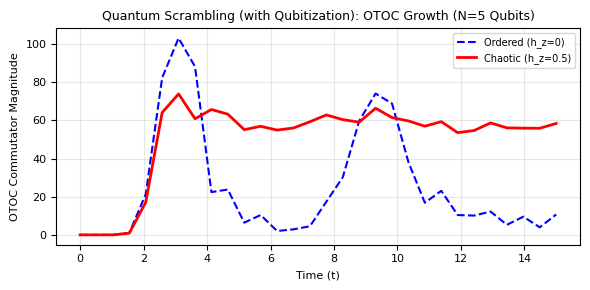

In [ ]:
# @title OTOC: On Chaotic Hamiltonian (Mixed-field Ising model)

# OTOC (Quantum Dynamics, Quantum Chaos and Scrambling)
# ==========================================
# OTOC (Linear Algebra Implementation)
# ==========================================

from scipy.linalg import norm
from IPython.display import display, Markdown

print(40*"=")
print("OTOC (Quantum Dynamics, Quantum Chaos and Scrambling)")
print(40*"=")

display(Markdown(r"* §Simple chaotic Hamiltonian is mixed-field Ising: $H = \sum Z_i Z_{i+1} + h_x \sum X_i + h_z \sum Z_i$. Longitudinal field $h_z$ breaks integrability and turns it chaotic."))
display(Markdown(r"* **§OTOC** messen das Scrambling von Information. Wenn du einen Operator W(t) zu einer Zeit t hast und einen Operator V(0) zum Zeitpunkt 0, misst der OTOC $ \langle W^\dagger(t) V^\dagger(0) W(t) V(0) \rangle $, **wie stark diese Operatoren nach der Zeit t nicht mehr kommutieren**. QM Äquivalent zum Schmetterlingseffekt."))
display(Markdown(r"* **§OTOC** $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ is metric to quantify quantum chaos and rate of scrambling (quantum Lyapunov exponent). **Operator Spreading:** local operator $\hat{V}$ (Pauli gate) evolves under chaotic Hamiltonian into non-local operator $\hat{V}(t) = e^{iHt}\hat{V}e^{-iHt}$ (Eigenstate Thermalization)"))
display(Markdown(r"* **Chaotic growth:** in a scrambler, $C(t) \simeq \frac{2K}{N}\, e^{\lambda_L t}$ with $\lambda_L$ the **quantum Lyapunov exponent** (rate of scrambling)."))
display(Markdown(r"* **Operator size $n(t)$** — mean number of non-trivial Pauli factors in the Pauli-string decomposition of $W(t)$; grows exponentially until saturation: $\frac{dn}{dt} = \lambda_L\, n(t) \;\Rightarrow\; n(t) \sim e^{\lambda_L t}$"))
display(Markdown(r"* **Operator-size distribution** — probability that $W(t)$ has size $n$; $C(t)$ is its first moment: $P(n,t) = \sum_{I:\,n(I)=n} |c_I(t)|^2$, $\quad C(t) \propto \frac{\langle n(t)\rangle}{N}$"))
display(Markdown(r"* **Butterfly velocity $v_B$** — spatial speed of the operator front; slope of the OTOC light cone: $C(t,x) \sim \frac{1}{N}\, e^{\lambda_L (t - x/v_B)}$"))
display(Markdown(r"* §OTOC is calculated via sequence: ***Forward Evolution***: Apply Qubitization Walk $n$ times (simulating time $+t$). ***Perturbation***: Apply Butterfly operator $\hat{V}$ ($X$ gate). ***Backward Evolution***: Apply inverse Qubitization Walk $n$ times (simulating time $-t$). ***Measurement***: Apply probe operator $\hat{W}$ and check correlation."))
display(Markdown(r"* **§Four-Point Function:** evolve forward and backward in time: $W(t) = e^{iHt} W(0) e^{-iHt}$. Schrödinger (moving states) $\rightarrow$ Heisenberg (moving operators)"))
display(Markdown(r"* **§Time-Dependent Schrödinger** $|\Psi(t)\rangle = e^{-iHt} |\Psi(0)\rangle$ tells how state moves. OTOC describes if chaotic or ordered. Time-Dependent part hidden in $\hat{W}(t)$."))
display(Markdown(r"* **§Heisenberg Evolution** $\hat{W}(t) = e^{iHt} \hat{W}(0) e^{-iHt}$ to calculate $\hat{W}(t)$, where $e^{-iHt}$ is solution to Schrödinger. Without Schrödinger, no $\hat{W}(t)$ and no OTOC."))
display(Markdown(r"* **§Loschmidt Echo**: measure OTOC on QC: 1. Evolve forward ($e^{-iHt}$) 2. Perturbation ($\hat{V}$) 3. Evolve backward ($e^{+iHt}$ - time reversal) 4. Measure overlap"))
display(Markdown(r"* **Fast scrambling**: scrambling time is logarithmic in system size — black holes are conjectured to be the fastest scramblers in nature: $t_* \sim \frac{1}{\lambda_L} \ln N$"))
display(Markdown(r"* **Timescale hierarchy:** $t_{\text{therm}} \sim \mathcal{O}(1) \;<\; t_*^{\text{scrambling}} \sim \ln N \;<\; t_K^{\text{Krylov}} \sim e^{S}$"))
display(Markdown(r"* **Liouvillian** — superoperator generating Heisenberg evolution; its tridiagonalization defines the Krylov basis: $\mathcal{L} = [H, \cdot\,]$, $\quad O(t) = e^{i\mathcal{L}t} O$"))
display(Markdown(r"* **Lanczos recursion** — tridiagonal form of $\mathcal{L}$ on the Krylov chain; $b_n$ = hopping amplitudes between Krylov sites: $\mathcal{L}|O_n) = b_{n+1}|O_{n+1}) + b_n |O_{n-1})$"))
display(Markdown(r"* **Krylov complexity** — mean position on the Krylov chain; measures algebraic depth of operator evolution: $K(t) = \sum_n n\, |\varphi_n(t)|^2$"))
display(Markdown(r"* **Universal Operator Growth Hypothesis (UOGH)** — in non-integrable systems the $b_n$ grow linearly, with slope bounded by KMS analyticity: $b_n = \alpha n + \gamma + o(1)$, $\quad \alpha \leq \pi/\beta$"))
display(Markdown(r"* **Growth regimes:** $b_n \to \text{const} \Rightarrow K \sim t$ (integrable) $\;|\;$ $b_n \sim \sqrt{n} \Rightarrow K \sim t^2$ (free) $\;|\;$ $b_n \sim \alpha n \Rightarrow K \sim e^{2\alpha t}$ (chaotic)"))
display(Markdown(r"* **ETH ansatz (Srednicki)** — matrix elements of local operators in energy eigenstates: diagonal part thermal, off-diagonal exponentially suppressed: $A_{mn} = \mathcal{A}(\bar{E})\,\delta_{mn} + e^{-S(\bar{E})/2} f_A(\bar{E}, \omega)\, R_{mn}$"))
display(Markdown(r"* **ETH core insight**: a single energy eigenstate already looks thermal locally — the system thermalizes *locally* while remaining globally pure."))
display(Markdown(r"* **Classification:** Chaotic: ETH holds $\;|\;$ Integrable: GGE $\;|\;$ MBL: no thermalization"))
display(Markdown(r"*§An OTOC is defined as $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$. The core concept here is Operator Spreading. We want to see how a local operator $\hat{W}$ at time $0$ evolves into a complex, non-local operator $\hat{W}(t) = \hat{U}^\dagger(t) \hat{W}(0) \hat{U}(t)$ at time $t$. We are asking: How much does the future measurement of $W$ depend on a past perturbation $V$? - If the system is chaotic, $\hat{W}(t)$ spreads across the system and eventually fails to commute with $\hat{V}(0)$, causing the OTOC to grow.*"))
display(Markdown(r"* **§Quantum Chaos** (Right). Information scrambles (thermalizes). By t=20, system is perfect model for how information is hidden in Black Hole."))
display(Markdown(r"* **§Interaction strength $J$** increase makes slope steeper (information moves faster) and quantum chaos $h_z$ grows faster. Light Cone of Information Scrambling:"))

def get_unitary_from_circuit(qubits, t, h_x, h_z, steps=25):
    """
    Creates the Unitary Matrix U(t) for a specific Hamiltonian setup.
    H = Sum(Zi Zj) + h_x * Sum(Xi) + h_z * Sum(Zi)
    """
    circuit = cirq.Circuit()
    dt = t / steps
    n = len(qubits)

    for _ in range(steps):
        # 1. Interaction (ZZ) - The "Scrambler"
        for i in range(n - 1):
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))
            circuit.append(cirq.rz(rads=2 * dt).on(qubits[i+1]))
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # 2. Transverse Field (X) - The "Driver"
        if h_x != 0:
            for i in range(n):
                circuit.append(cirq.rx(rads=2 * h_x * dt).on(qubits[i]))

        # 3. Longitudinal Field (Z) - The "Chaos Generator"
        # Adding this term breaks integrability and causes chaos.
        if h_z != 0:
            for i in range(n):
                circuit.append(cirq.rz(rads=2 * h_z * dt).on(qubits[i]))

    # Extract the full unitary matrix (2^N x 2^N)
    return cirq.unitary(circuit)

def calculate_otoc_curve(num_qubits, h_x, h_z, time_points):
    """
    Calculates the OTOC C(t) = || [W(t), V] ||^2
    V = X on Qubit 0 (The Perturbation)
    W = Z on Qubit N-1 (The Probe)
    """
    qubits = cirq.LineQubit.range(num_qubits)
    otoc_values = []

    # Define Operators V (at t=0) and W (at t=0)
    # We build them as full matrices (2^N x 2^N)

    # V = X_0 (Tensor product: X I I I...)
    op_list_V = [np.eye(2)] * num_qubits
    op_list_V[0] = np.array([[0, 1], [1, 0]]) # X
    V = op_list_V[0]
    for i in range(1, num_qubits):
        V = np.kron(V, op_list_V[i])

    # W = Z_last (Tensor product: ...I I I Z)
    op_list_W = [np.eye(2)] * num_qubits
    op_list_W[-1] = np.array([[1, 0], [0, -1]]) # Z
    W = op_list_W[-1]
    for i in range(num_qubits-2, -1, -1):
        W = np.kron(op_list_W[i], W)

    #print(f"Simulating: h_x={h_x}, h_z={h_z}...")

    for t in time_points:
        if t == 0:
            otoc_values.append(0)
            continue

        # 1. Get Time Evolution Operator U(t)
        U = get_unitary_from_circuit(qubits, t, h_x, h_z)
        U_dag = U.conj().T

        # 2. Evolve W forward in time (Heisenberg Picture)
        # W(t) = U^dagger * W * U
        W_t = U_dag @ W @ U

        # 3. Calculate Commutator C = [W(t), V] = W(t)V - VW(t)
        commutator = W_t @ V - V @ W_t

        # 4. Measure "Size" of commutator (Frobenius Norm)
        # This tells us how non-commutative they have become
        c_val = np.linalg.norm(commutator) ** 2
        otoc_values.append(c_val)

    return otoc_values

# --- Simulation Setup ---
# A simple chaotic Hamiltonian is the mixed-field Ising model:

n_qubits = 5  # Small enough for matrix multiplication
times = np.linspace(0, 15.0, 30)

# Scenario 1: Ordered / Integrable (Ising Model)
# No longitudinal field (h_z = 0)
otoc_ordered = calculate_otoc_curve(n_qubits, h_x=1.0, h_z=0.0, time_points=times)

# Scenario 2: Chaotic (Non-Integrable)
# We add a longitudinal field (h_z = 0.5) to break symmetry
otoc_chaotic = calculate_otoc_curve(n_qubits, h_x=1.0, h_z=0.5, time_points=times)

# --- Plotting ---
plt.figure(figsize=(6, 3))
small_size = 8 # font size
plt.plot(times, otoc_ordered, label='Ordered (h_z=0)', color='blue', linestyle='--')
plt.plot(times, otoc_chaotic, label='Chaotic (h_z=0.5)', color='red', linewidth=2)
plt.title(f'Quantum Scrambling (with Qubitization): OTOC Growth (N={n_qubits} Qubits)', fontsize=small_size + 1)
plt.xlabel('Time (t)', fontsize=small_size)
plt.ylabel('OTOC Commutator Magnitude', fontsize=small_size)
plt.legend(fontsize=small_size - 1) # fint size on legend slightly smaller
plt.tick_params(axis='both', labelsize=small_size)

plt.grid(True, alpha=0.3)
plt.tight_layout() # Ensures labels don't get cut off at smaller sizes
plt.show()